Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings("ignore")

Load Dataset

In [2]:
df = pd.read_csv("student_data.csv")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


Dataset Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

Check Dataset Shape

In [4]:
print("Rows and Columns:", df.shape)

Rows and Columns: (395, 33)


Check Missing Values

In [5]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Statistical Summary

In [6]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


EDA (Exploratory Data Analysis)

Chart 1 - Final Grade Distribution (G3)

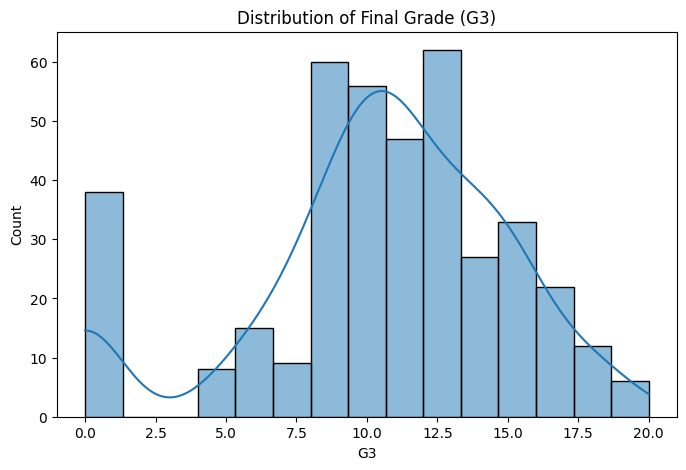

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['G3'], bins=15, kde=True)
plt.title('Distribution of Final Grade (G3)')
plt.show()

Chart 2 - Study Time vs Final Grade

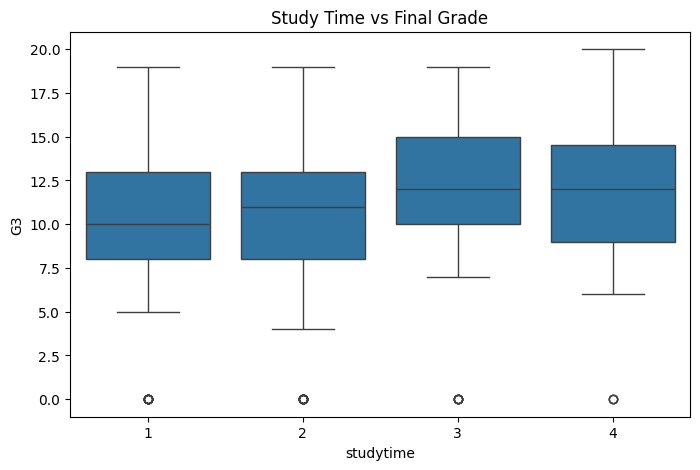

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(x='studytime', y='G3', data=df)
plt.title('Study Time vs Final Grade')
plt.show()

Absences vs Final Grade

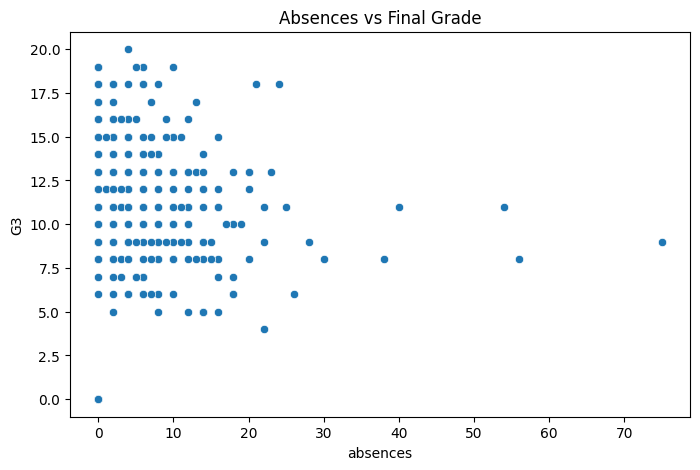

In [9]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='absences', y='G3', data=df)
plt.title('Absences vs Final Grade')
plt.show()

Chart 4 - Correlation Heatmap

In [10]:
df_encoded = df.copy()

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = le.fit_transform(df_encoded[col])

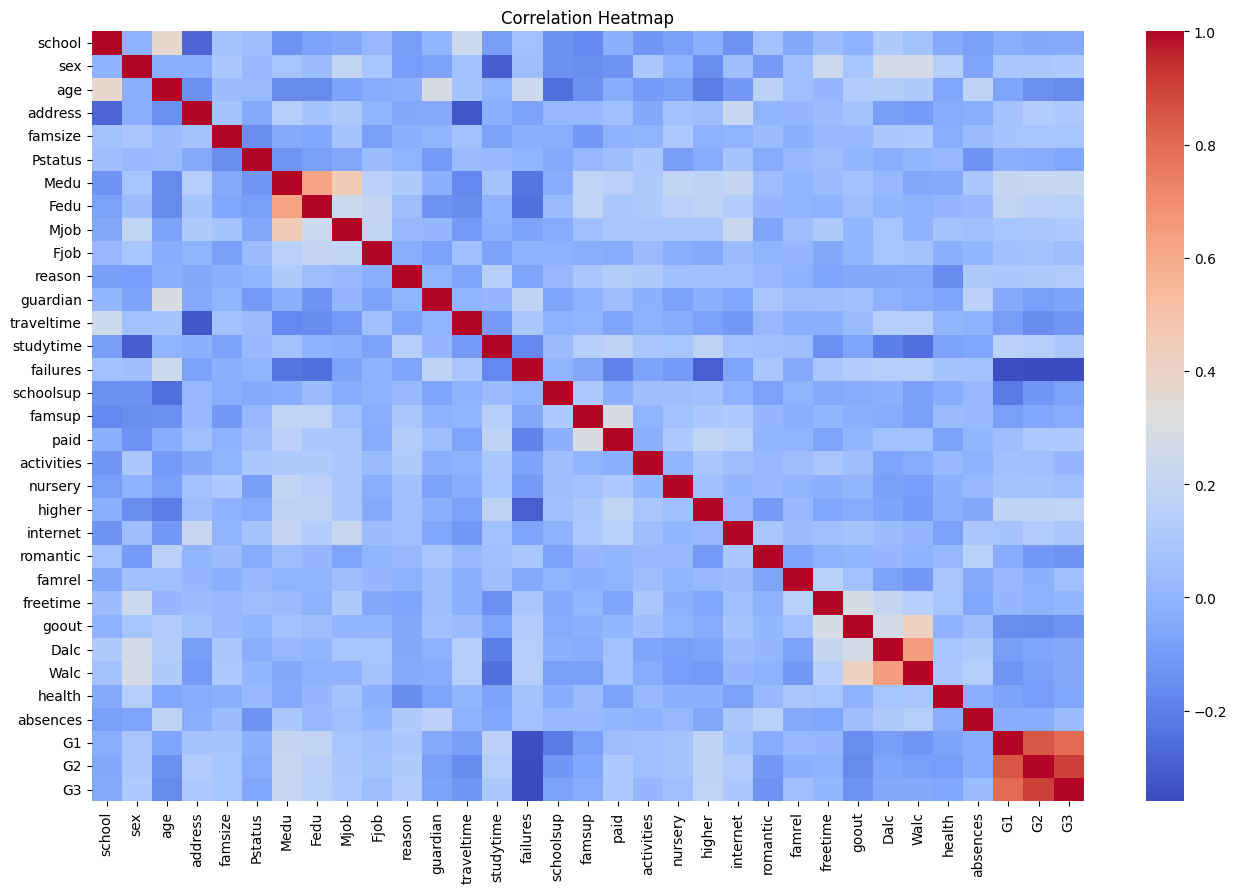

In [11]:
plt.figure(figsize=(16,10))
sns.heatmap(df_encoded.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Chart 5 - Gender vs Final Grade

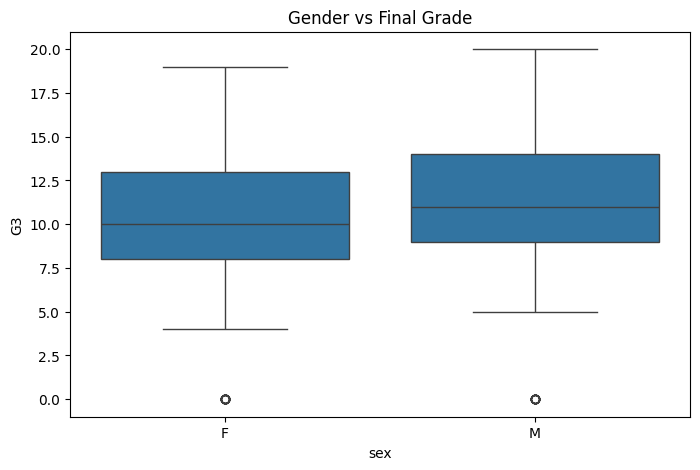

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x='sex', y='G3', data=df)
plt.title('Gender vs Final Grade')
plt.show()

DATA PREPROCESSING

Encode Categorical Columns

In [13]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

le = LabelEncoder()

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0,0,18,1,0,0,4,4,0,4,...,4,3,4,1,1,3,6,5,6,6
1,0,0,17,1,0,1,1,1,0,2,...,5,3,3,1,1,3,4,5,5,6
2,0,0,15,1,1,1,1,1,0,2,...,4,3,2,2,3,3,10,7,8,10
3,0,0,15,1,0,1,4,2,1,3,...,3,2,2,1,1,5,2,15,14,15
4,0,0,16,1,0,1,3,3,2,2,...,4,3,2,1,2,5,4,6,10,10


Experiment 1
Predict G3 WITHOUT G1 and G2.

In [14]:
X = df_encoded.drop(['G1','G2','G3'], axis=1)

y = df_encoded['G3']

print(X.shape)
print(y.shape)

(395, 30)
(395,)


Train Test Split

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(316, 30)
(79, 30)


Linear Regression

In [16]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

Evaluate Linear Regression

In [17]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr) ** 0.5
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

Linear Regression Results
MAE: 3.4948497013642132
RMSE: 4.306234278514978
R2: 0.0956541860629222


Decision Tree

In [18]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

Evaluate Decision Tree

In [19]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = mean_squared_error(y_test, y_pred_dt) ** 0.5
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("MAE:", mae_dt)
print("RMSE:", rmse_dt)
print("R2:", r2_dt)

Decision Tree Results
MAE: 3.6202531645569622
RMSE: 4.8103264448817935
R2: -0.12846560185040468


Random Forest

In [20]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

Evaluate Random Forest

In [21]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

Random Forest Results
MAE: 2.995822784810126
RMSE: 3.718379427871805
R2: 0.3257101342481168


Compare Models

In [22]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'MAE': [
        mae_lr,
        mae_dt,
        mae_rf
    ],
    'RMSE': [
        rmse_lr,
        rmse_dt,
        rmse_rf
    ],
    'R2 Score': [
        r2_lr,
        r2_dt,
        r2_rf
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,3.494850,4.306234,0.095654
1,Decision Tree,3.620253,4.810326,-0.128466
2,Random Forest,2.995823,3.718379,0.325710


EXPERIMENT 2
Predict G3 WITH G1 and G2 included

In [23]:
X2 = df_encoded.drop('G3', axis=1)

y2 = df_encoded['G3']

print(X2.shape)

(395, 32)


Train/Test Split

In [24]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42
)

Linear Regression

In [25]:
lr2 = LinearRegression()

lr2.fit(X2_train, y2_train)

pred_lr2 = lr2.predict(X2_test)

Evaluate

In [26]:
mae_lr2 = mean_absolute_error(y2_test, pred_lr2)
rmse_lr2 = mean_squared_error(y2_test, pred_lr2) ** 0.5
r2_lr2 = r2_score(y2_test, pred_lr2)

print(mae_lr2)
print(rmse_lr2)
print(r2_lr2)

1.4954750100522758
2.2432998258963823
0.7545777855043501


Decision Tree

In [27]:
dt2 = DecisionTreeRegressor(random_state=42)

dt2.fit(X2_train, y2_train)

pred_dt2 = dt2.predict(X2_test)

Evaluate

In [28]:
mae_dt2 = mean_absolute_error(y2_test, pred_dt2)
rmse_dt2 = mean_squared_error(y2_test, pred_dt2) ** 0.5
r2_dt2 = r2_score(y2_test, pred_dt2)

print(mae_dt2)
print(rmse_dt2)
print(r2_dt2)

1.3037974683544304
2.378702976014716
0.7240568249304535


Random Forest

In [29]:
rf2 = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf2.fit(X2_train, y2_train)

pred_rf2 = rf2.predict(X2_test)

In [ ]:
Evaluate

In [30]:
mae_rf2 = mean_absolute_error(y2_test, pred_rf2)
rmse_rf2 = mean_squared_error(y2_test, pred_rf2) ** 0.5
r2_rf2 = r2_score(y2_test, pred_rf2)

print(mae_rf2)
print(rmse_rf2)
print(r2_rf2)

1.1050632911392408
1.867281920908543
0.8299569015097052


Create Comparison Table

In [31]:
results2 = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'MAE': [
        mae_lr2,
        mae_dt2,
        mae_rf2
    ],
    'RMSE': [
        rmse_lr2,
        rmse_dt2,
        rmse_rf2
    ],
    'R2 Score': [
        r2_lr2,
        r2_dt2,
        r2_rf2
    ]
})

results2

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.495475,2.243300,0.754578
1,Decision Tree,1.303797,2.378703,0.724057
2,Random Forest,1.105063,1.867282,0.829957


Random Forest from Experiment 2.

In [32]:
import pickle

pickle.dump(rf2, open("model.pkl", "wb"))

print("Model Saved Successfully")

Model Saved Successfully


Feature Importance Chart

In [33]:
feature_importance = pd.DataFrame({
    'Feature': X2.columns,
    'Importance': rf2.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

       Feature  Importance
31          G2    0.792518
29    absences    0.110344
2          age    0.015196
10      reason    0.010257
30          G1    0.007557
23      famrel    0.006354
8         Mjob    0.006137
22    romantic    0.005654
28      health    0.004655
18  activities    0.004456


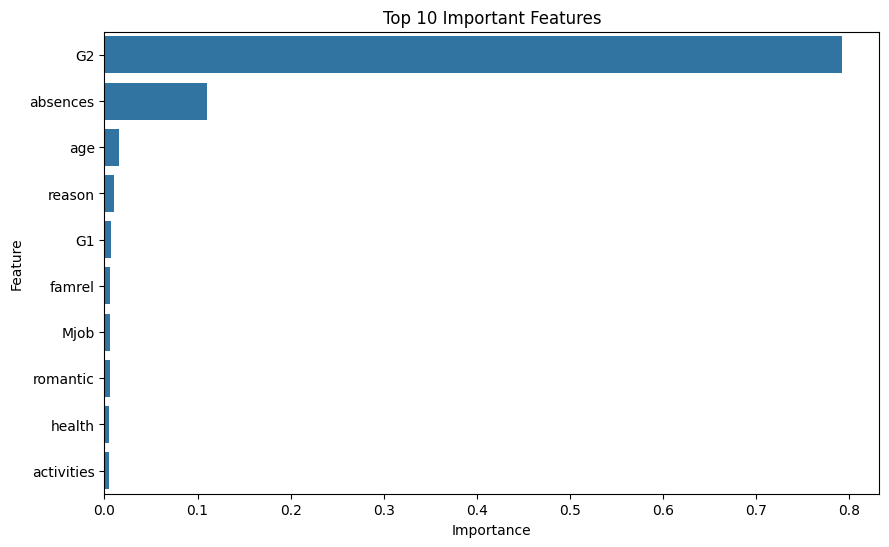

In [34]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")
plt.show()

Prediction vs Actual Chart

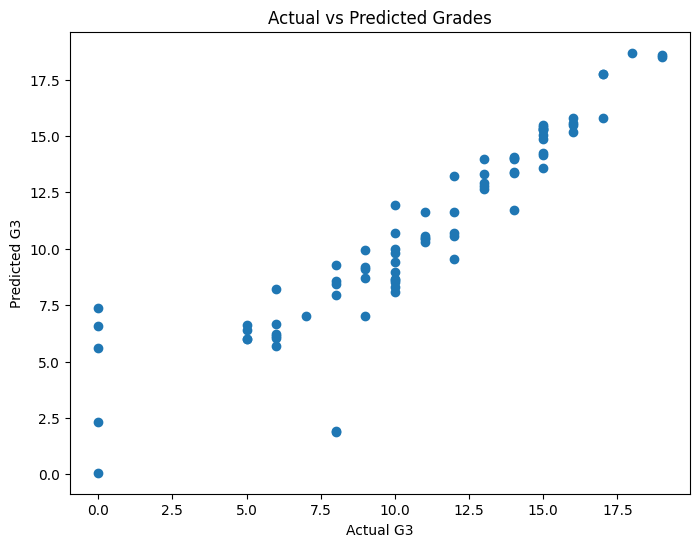

In [35]:
plt.figure(figsize=(8,6))

plt.scatter(y2_test, pred_rf2)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")

plt.title("Actual vs Predicted Grades")

plt.show()

In [36]:
print(X2.columns.tolist())

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']


In [37]:
for i, col in enumerate(X2.columns):
    print(i, col)

0 school
1 sex
2 age
3 address
4 famsize
5 Pstatus
6 Medu
7 Fedu
8 Mjob
9 Fjob
10 reason
11 guardian
12 traveltime
13 studytime
14 failures
15 schoolsup
16 famsup
17 paid
18 activities
19 nursery
20 higher
21 internet
22 romantic
23 famrel
24 freetime
25 goout
26 Dalc
27 Walc
28 health
29 absences
30 G1
31 G2


In [39]:
df_encoded[['school','sex','address','famsize','Pstatus']].head()

,school,sex,address,famsize,Pstatus
0,0,0,1,0,0
1,0,0,1,0,1
2,0,0,1,1,1
3,0,0,1,0,1
4,0,0,1,0,1


In [40]:
for col in ['Mjob','Fjob','reason','guardian',
            'schoolsup','famsup','paid',
            'activities','nursery','higher',
            'internet','romantic']:
    print("\n", col)
    print(df[[col]].drop_duplicates().sort_values(col))


 Mjob
        Mjob
0    at_home
3     health
4      other
5   services
10   teacher

 Fjob
        Fjob
32   at_home
10    health
1      other
3   services
0    teacher

 reason
       reason
0      course
3        home
2       other
5  reputation

 guardian
   guardian
1    father
0    mother
14    other

 schoolsup
  schoolsup
1        no
0       yes

 famsup
  famsup
0     no
1    yes

 paid
  paid
0   no
2  yes

 activities
  activities
0         no
3        yes

 nursery
  nursery
1      no
0     yes

 higher
   higher
78     no
0     yes

 internet
  internet
0       no
1      yes

 romantic
  romantic
0       no
3      yes


In [41]:
for col in ['Mjob','Fjob','reason','guardian',
            'schoolsup','famsup','paid',
            'activities','nursery','higher',
            'internet','romantic']:
    print("\n", col)
    print(df_encoded[[col]].drop_duplicates().sort_values(col))


 Mjob
    Mjob
0      0
3      1
4      2
5      3
10     4

 Fjob
    Fjob
32     0
10     1
1      2
3      3
0      4

 reason
   reason
0       0
3       1
2       2
5       3

 guardian
    guardian
1          0
0          1
14         2

 schoolsup
   schoolsup
1          0
0          1

 famsup
   famsup
0       0
1       1

 paid
   paid
0     0
2     1

 activities
   activities
0           0
3           1

 nursery
   nursery
1        0
0        1

 higher
    higher
78       0
0        1

 internet
   internet
0         0
1         1

 romantic
   romantic
0         0
3         1
